# Local Variation + GNN iterative

## Import

In [7]:
import os
import sys
import numpy as np

import warnings
warnings.filterwarnings("ignore")

# pygsp
from pygsp import graphs

# scipy
import scipy as sp

# torch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# torch geometric
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected

# sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# datasets
data_path = os.path.abspath(os.path.join("..", "data"))
if data_path not in sys.path:
    sys.path.append(data_path)
from cora.load_cora import load_cora_dataset

# plot
import matplotlib.pyplot as plt

# utils
from utils.split_dataset import *
from utils.visualization import *
from utils.coarsening import apply_Loukas_coarsening, create_pygsp_graph


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(1)
np.random.seed(1)


Using device: cuda


## Global data

- `NODE_IDS`: list of nodes ids
- `FEATURES`: (N x D) matrix of features for each node
- `LABELS`: (N) list of true labels for each node
- `EDGES_IDX`: (M, 2) matrix of edges
- `IDX_MAP`: dict mapping original node IDs to index

In [8]:
# load dataset and gloa
NODE_IDS, FEATURES, LABELS, EDGES_IDX, IDX_MAP = load_cora_dataset(log_info=False)
LABELS_ENCODED = LabelEncoder().fit_transform(LABELS)

## General functions

### Get coarsened data from Coarsening matrix C

In [9]:
def get_coarsened_edges_and_features(C: list, Gc: graphs.Graph, features):
    """
    Coarsen edges and features based on the coarsening matrix C;
    the feature matrix (N x D) is made by summing up features from nodes that are coarsened into the same supernode.

    Output:
      - Gc: coarsened edges index (num_edges, 2)
      - features_coarsened: coarsened features (num_nodes_coarsened, num_features)
    """

    idx_map = {} # map fine node -> coarse node 
    for supernode, node in zip(*C.nonzero()):
        idx_map[node] = supernode
        
    # features coarsened
    features_coarsened = C @ features
    
    # edges coarsened
    edges_idx_coarsened = np.array(Gc.get_edge_list()[:2]).T

    return edges_idx_coarsened, features_coarsened


def get_coarsened_edges_features_labels(C: list, Gc: graphs.Graph, features, labels, priority_label=0):
    """
    Coarsen edges and features based on the coarsening matrix C;
    the feature matrix (N x D) is made by summing up features from nodes that are coarsened into the same supernode.

    Output:
      - edges_idx_coarsened: coarsened edges index (num_edges, 2)
      - features_coarsened: coarsened features (num_nodes_coarsened, num_features)
      - labels_coarsened: coarsened labels (num_nodes_coarsened,)
    """

    idx_map = {} # map fine node -> coarse node 
    for supernode, node in zip(*C.nonzero()):
        idx_map[node] = supernode
        
    # features coarsened
    features_coarsened = C @ features

    # edges coarsened
    edges_idx_coarsened = np.array(Gc.get_edge_list()[:2]).T

    # labels coarsened
    num_classes = len(np.unique(labels))
    all_labels = np.zeros((C.shape[0], num_classes), dtype=np.float32)
    for supernode, node in zip(*C.nonzero()):
        all_labels[supernode, labels[node]] += 1

    labels_coarsened = np.zeros(C.shape[0], dtype=np.int64)
    for supernode in range(C.shape[0]):
        mx = np.argmax(all_labels[supernode])
        priority_count = all_labels[supernode, priority_label]
        if priority_count >= mx:
            labels_coarsened[supernode] = priority_label
        else: 
            labels_coarsened[supernode] = mx

    return edges_idx_coarsened, features_coarsened, labels_coarsened

## GNN

### model and training function

In [10]:
class GCN(nn.Module):
    def __init__(self, nfeat, nhid, nclass, dropout=.5):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(nfeat, nhid)
        self.conv2 = GCNConv(nhid, nclass)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)
    
    def get_embeddings(self, x, edge_index):
        x = x.to(next(self.parameters()).device)
        edge_index = edge_index.to(x.device) 
        x = F.relu(self.conv1(x, edge_index))
        return x
    
    def reset_parameters(self):
        self.conv1.reset_parameters()
        self.conv2.reset_parameters()

In [11]:
def create_pyg_data(features, edges_idx, labels) -> Data:
    x = torch.FloatTensor(features.astype(np.float32))
    y = torch.LongTensor(labels)
    edge_index = torch.LongTensor(edges_idx.T)  # expects (2, num_edges)
    edge_index = to_undirected(edge_index)
        
    return Data(x=x, edge_index=edge_index, y=y)

def train_gnn(model: nn.Module, optimizer: optim.Optimizer, data: Data, train_idx: list, val_idx: list, epochs=200, log_info=True):
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    data = data.to(next(model.parameters()).device)
    model.reset_parameters()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        output = model(data.x, data.edge_index)

        # train
        loss_train = F.nll_loss(output[train_idx], data.y[train_idx])
        loss_train.backward()
        optimizer.step()
        
        # validate
        model.eval()
        with torch.no_grad():
            output = model(data.x, data.edge_index)
            loss_val = F.nll_loss(output[val_idx], data.y[val_idx])
            pred_val = output[val_idx].max(1)[1]
            acc_val = accuracy_score(data.y[val_idx].cpu().numpy(), pred_val.cpu().numpy())
        
        # save data
        train_losses.append(loss_train.item())
        val_losses.append(loss_val.item())
        val_accuracies.append(acc_val)
        
        # log info
        if epoch % 10 == 0 and log_info:
            print(f'Epoch {epoch:03d}, Train Loss: {loss_train:.4f}, '
                  f'Val Loss: {loss_val:.4f}, Val Acc: {acc_val:.4f}')
    
    return train_losses, val_losses, val_accuracies

def evaluate_model(model: nn.Module, data: Data, test_idx, log_info=True):
    """Evaluate the model on test set."""
    model.eval()
    data = data.to(next(model.parameters()).device)
    
    with torch.no_grad():
        output = model(data.x, data.edge_index)
        pred_test = output[test_idx].max(1)[1]
        acc_test = accuracy_score(data.y[test_idx].cpu().numpy(), pred_test.cpu().numpy())
        
        if log_info:
            print(f'\nTest Accuracy: {acc_test:.4f}')
            print('\nClassification Report:')
            print(classification_report(
                data.y[test_idx].cpu().numpy(), pred_test.cpu().numpy())
            )

    return acc_test, pred_test

## `Coarsen - GNN and Loss` iteration

**workflow:**
```latex
1. Train GNN on full graph to initialize weights
2. Iterate:
    1. generate embeddings of all nodes from GNN(A, X)
    2. coarsen the graph using embeddings as node features
    3. Train GNN on coarsened
```

In [ ]:
# model
nfeat = FEATURES.shape[1]  # 1433
nhid = 128
nclass = len(np.unique(LABELS_ENCODED))  # 7
dropout = 0.1
model = GCN(nfeat=nfeat, nhid=nhid, nclass=nclass, dropout=dropout).to(device)

# train data
wd = 5e-3
lr = 0.001
epochs = 300
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

# initialize the GNN to produce first embeddings
data = create_pyg_data(FEATURES, EDGES_IDX, LABELS_ENCODED)
# train_idx, val_idx, test_idx = create_train_val_test_split(data.num_nodes)
# train_idx = torch.LongTensor(train_idx).to(device)
# val_idx = torch.LongTensor(val_idx).to(device)
# test_idx = torch.LongTensor(test_idx).to(device)
# t_losses, v_losses, v_accuracies = train_gnn(
#     model, optimizer, data, train_idx, val_idx, epochs=epochs, log_info=False
# )

ratio = 0.8
method = 'variation_edges'
max_iter = 50
x, ycrs, yfine = [], [], []
for iterate in range(max_iter):
    print(f"Iteration {iterate + 1:02d}/{max_iter}")

    # get embeddings from the GNN
    embeddings = model.get_embeddings(data.x, data.edge_index)

    # coarsen the graph using embeddings as features
    G = create_pygsp_graph(EDGES_IDX, data.num_nodes)
    C, Gc, Call, Gall = apply_Loukas_coarsening(
        G, X=embeddings, method=method, ratio=ratio, K=50, log_info=True
    )

    # train the GNN on the coarsened graph
    edges_idx_c, feat_c, labels_C = get_coarsened_edges_features_labels(
        C, Gc, FEATURES, LABELS_ENCODED, priority_label=0
    )
    data_c = create_pyg_data(feat_c, edges_idx_c, labels_C)
    train_idx_c, val_idx_c, test_idx_c = create_train_val_test_split(data_c.num_nodes)
    train_idx_c = torch.LongTensor(train_idx_c).to(device)
    val_idx_c = torch.LongTensor(val_idx_c).to(device)
    test_idx_c = torch.LongTensor(test_idx_c).to(device)
    t_losses_c, v_losses_c, v_accuracies_c = train_gnn(
        model, optimizer, data_c, train_idx_c, val_idx_c, epochs=epochs, log_info=False
    )
    
    print(f"Validation accuracy: {v_accuracies_c[-1]}")
    
    # evaluate the model on the coarsened graph
    acc_test_c, pred_test_c = evaluate_model(model, data_c, test_idx_c, log_info=False)

    # evaluate on original (fine) graph
    pred_fine = np.array([-1 for _ in range(NODE_IDS.shape[0])], dtype=np.int64)
    tot = 0
    for idx in range(len(test_idx_c)):
        test_supernode = test_idx_c[idx]
        for fine_node in C.getrow(test_supernode).nonzero()[1]:
            pred_fine[fine_node] = pred_test_c[idx]
            tot += 1

    sm = sum(pred_fine == LABELS_ENCODED)
    accuracy_fine = sm / tot

    print(f"Test - coarse accuracy: {acc_test_c:.4f}, fine accuracy: {accuracy_fine:.4f}\n")

    # plotting data
    x.append(iterate)
    ycrs.append(acc_test_c)
    yfine.append(accuracy_fine)


# save data
# np.save(f'saves/data_iterative_feat_t075.npy', {
#        'x': x,
#        'ycrs': ycrs,
#        'yfine': yfine,
#        'description': f'Data obtained using: {ratio=}, {method=}, {max_iter=}'
#     })

# plot the results
# plt.figure(figsize=(10, 5))
# plt.plot(x, ycrs, label='Coarse Accuracy', color='tab:blue')
# plt.plot(x, yfine, label='Fine Accuracy', linestyle=':', color='tab:blue')
# plt.legend()
# plt.xlabel('Iteration')
# plt.ylabel('Accuracy')
# plt.title('Coarse vs Fine Accuracy over Iterations')
# plt.show()

# ~15 mins

Iteration 01/50
Coarsening: variation_edges (2708 n, 5278 e) -> (542 n, 1019 e); 
Validation accuracy: 0.7962962962962963
Test - coarse accuracy: 0.7431, fine accuracy: 0.6478

Iteration 02/50
Coarsening: variation_edges (2708 n, 5278 e) -> (542 n, 796 e); 
Validation accuracy: 0.7129629629629629
Test - coarse accuracy: 0.7890, fine accuracy: 0.7189

Iteration 03/50
Coarsening: variation_edges (2708 n, 5278 e) -> (542 n, 1281 e); 
Validation accuracy: 0.8333333333333334
Test - coarse accuracy: 0.7890, fine accuracy: 0.7717

Iteration 04/50
Coarsening: variation_edges (2708 n, 5278 e) -> (542 n, 1294 e); 
Validation accuracy: 0.8240740740740741
Test - coarse accuracy: 0.8165, fine accuracy: 0.7816

Iteration 05/50
Coarsening: variation_edges (2708 n, 5278 e) -> (542 n, 1292 e); 
Validation accuracy: 0.8240740740740741
Test - coarse accuracy: 0.8073, fine accuracy: 0.7918

Iteration 06/50
Coarsening: variation_edges (2708 n, 5278 e) -> (542 n, 1289 e); 
Validation accuracy: 0.81481481481

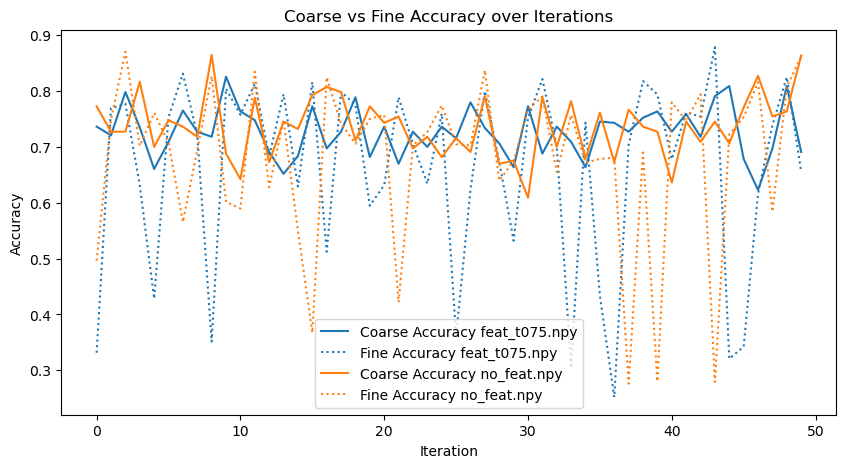

In [13]:
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
saved = ['saves/data_iterative_feat_t075.npy', 'saves/data_iterative_no_feat.npy']
plt.figure(figsize=(10, 5))
for c, d in zip(colors, saved):
    data = np.load(d, allow_pickle=True).item()
    name = d.split('iterative_')[-1]
    plt.plot(data['x'], data['ycrs'], label=f'Coarse Accuracy {name}', color=c)
    plt.plot(data['x'], data['yfine'], label=f'Fine Accuracy {name}', linestyle=':', color=c)
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Coarse vs Fine Accuracy over Iterations')
plt.show()